# Biomarker Comparison: Cognitive Stress vs Physical Stress

**Goal**: Determine if we can distinguish **cognitive stress** from **physical stress** (aerobic/anaerobic exercise) using wearable biosignals.

**Key Question**: *Can we really distinguish cognitive stress apart from aerobic/anaerobic?*

### Why It Matters
- All three conditions (cognitive stress, aerobic, anaerobic) elevate HR and movement
- If biomarkers overlap significantly, a stress classifier trained on lab data may misclassify exercise as stress
- This analysis validates whether a 2-stage pipeline (Activity Classification → Stress Detection) is necessary

### Analysis Outline
1. **Data Loading**: Preprocessed WISE data with sliding windows + per-subject HRV imputation
2. **Statistical Comparison**: ANOVA + post-hoc tests to identify discriminative features
3. **Visualizations**: Feature distributions across activity types
4. **3-Class Classifier**: COGNITIVE vs AEROBIC vs ANAEROBIC
5. **2-Class Classifier**: PHYSICAL vs COGNITIVE (recommended approach)
6. **Steps as ACC Proxy**: Validation for Apple Watch deployment
7. **Summary**: Findings and deployment recommendations

In [1]:
import _setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from scipy.stats import f_oneway, ttest_ind
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_validate, LeaveOneGroupOut, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix

from pipeline.preprocess_wise import df_activity, WINDOW_SIZE_SEC, WINDOW_OVERLAP

df_combined = df_activity.copy()
df_combined['subject_id'] = df_combined['subject']

print(f"Dataset: {len(df_combined)} windows from {df_combined['subject_id'].nunique()} subjects")
print(f"Window: {WINDOW_SIZE_SEC}s, {WINDOW_OVERLAP*100:.0f}% overlap\n")
print(df_combined['activity_type'].value_counts())

Loading stress data...
  Loading STRESS protocol...
  Loading AEROBIC protocol...
  Loading ANAEROBIC protocol...

df_features (STRESS protocol):  3273 windows from 22 subjects
  Labels: {'REST': 2860, 'STRESS': 413}
df_activity (ALL 3 protocols):  2449 windows from 22 subjects
  Activity types: {'AEROBIC': 1968, 'COGNITIVE': 413, 'ANAEROBIC': 68}

Preprocessing applied:
  - Sliding windows: 30s, 50% overlap
  - Per-subject HRV imputation (Lev's fix)
  - Features: ['SDNN', 'RMSSD', 'EDA_mean', 'EDA_std', 'HR_mean', 'HR_std', 'HR_max', 'TEMP_mean', 'TEMP_std', 'ACC_mean', 'ACC_std']
  - Apple Watch features: ['HR_mean', 'HR_std', 'HR_max', 'SDNN', 'RMSSD', 'ACC_mean', 'ACC_std']

Ready.
Dataset: 2449 windows from 22 subjects
Window: 30s, 50% overlap

activity_type
AEROBIC      1968
COGNITIVE     413
ANAEROBIC      68
Name: count, dtype: int64


---
## 1. Statistical Comparison: ANOVA + Post-hoc Tests

**Objective**: Identify which biomarkers significantly differ across the three activity types.

**Method**: 
- One-way ANOVA to test if means differ across groups
- Post-hoc pairwise t-tests for significant features

**Hypotheses**:
- Movement features (ACC) should distinguish all three types
- HR should distinguish COGNITIVE from PHYSICAL but not AEROBIC from ANAEROBIC
- EDA and TEMP may differ but with smaller effect sizes

In [15]:
biomarkers = ['SDNN', 'RMSSD', 'EDA_mean', 'EDA_std', 'HR_mean', 'HR_std', 
              'TEMP_mean', 'TEMP_std', 'ACC_mean', 'ACC_std']
biomarkers = [b for b in biomarkers if b in df_combined.columns]

print("ANOVA: COGNITIVE vs AEROBIC vs ANAEROBIC")
print(f"{'='*80}")
print(f"{'Feature':<12} {'F-stat':<10} {'p-value':<12} {'Sig':<5}")
print("-" * 80)

anova_results = []
for bio in biomarkers:
    cognitive = df_combined[df_combined['activity_type'] == 'COGNITIVE'][bio].dropna()
    aerobic = df_combined[df_combined['activity_type'] == 'AEROBIC'][bio].dropna()
    anaerobic = df_combined[df_combined['activity_type'] == 'ANAEROBIC'][bio].dropna()
    
    if len(cognitive) > 2 and len(aerobic) > 2 and len(anaerobic) > 2:
        f_stat, p_val = f_oneway(cognitive, aerobic, anaerobic)
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        print(f"{bio:<12} {f_stat:<10.2f} {p_val:<12.6f} {sig:<5}")
        
        anova_results.append({
            'biomarker': bio, 'f_stat': f_stat, 'p_value': p_val, 'significant': sig != 'ns'
        })

df_anova = pd.DataFrame(anova_results)
significant_biomarkers = df_anova[df_anova['significant']]['biomarker'].tolist()
print(f"\nSignificant features (p<0.05): {len(significant_biomarkers)}/{len(biomarkers)}")

ANOVA: COGNITIVE vs AEROBIC vs ANAEROBIC
Feature      F-stat     p-value      Sig  
--------------------------------------------------------------------------------
SDNN         3.35       0.035191     *    
RMSSD        15.74      0.000000     ***  
EDA_mean     8.60       0.000190     ***  
EDA_std      35.54      0.000000     ***  
HR_mean      71.96      0.000000     ***  
HR_std       40.28      0.000000     ***  
TEMP_mean    22.90      0.000000     ***  
TEMP_std     0.54       0.580444     ns   
ACC_mean     825.95     0.000000     ***  
ACC_std      632.93     0.000000     ***  

Significant features (p<0.05): 9/10


In [16]:
# Post-hoc pairwise tests for top features only
print("\nPost-hoc Pairwise Tests (Top 3 Features by F-statistic):")
print("="*60)

top_features = df_anova.nlargest(3, 'f_stat')['biomarker'].tolist()
for bio in top_features:
    cognitive = df_combined[df_combined['activity_type'] == 'COGNITIVE'][bio].dropna()
    aerobic = df_combined[df_combined['activity_type'] == 'AEROBIC'][bio].dropna()
    anaerobic = df_combined[df_combined['activity_type'] == 'ANAEROBIC'][bio].dropna()
    
    print(f"\n{bio}:")
    t1, p1 = ttest_ind(cognitive, aerobic, equal_var=False)
    t2, p2 = ttest_ind(cognitive, anaerobic, equal_var=False)
    t3, p3 = ttest_ind(aerobic, anaerobic, equal_var=False)
    
    print(f"  COGNITIVE vs AEROBIC:   p={p1:.4f}")
    print(f"  COGNITIVE vs ANAEROBIC: p={p2:.4f}")
    print(f"  AEROBIC vs ANAEROBIC:   p={p3:.4f}")


Post-hoc Pairwise Tests (Top 3 Features by F-statistic):

ACC_mean:
  COGNITIVE vs AEROBIC:   p=0.0000
  COGNITIVE vs ANAEROBIC: p=0.0000
  AEROBIC vs ANAEROBIC:   p=0.0000

ACC_std:
  COGNITIVE vs AEROBIC:   p=0.0000
  COGNITIVE vs ANAEROBIC: p=0.0000
  AEROBIC vs ANAEROBIC:   p=0.0000

HR_mean:
  COGNITIVE vs AEROBIC:   p=0.0000
  COGNITIVE vs ANAEROBIC: p=0.0000
  AEROBIC vs ANAEROBIC:   p=0.8013


---
## 2. Visualizations

Box plots show the distribution of the top 6 most discriminative features (by F-statistic) across the three activity types.

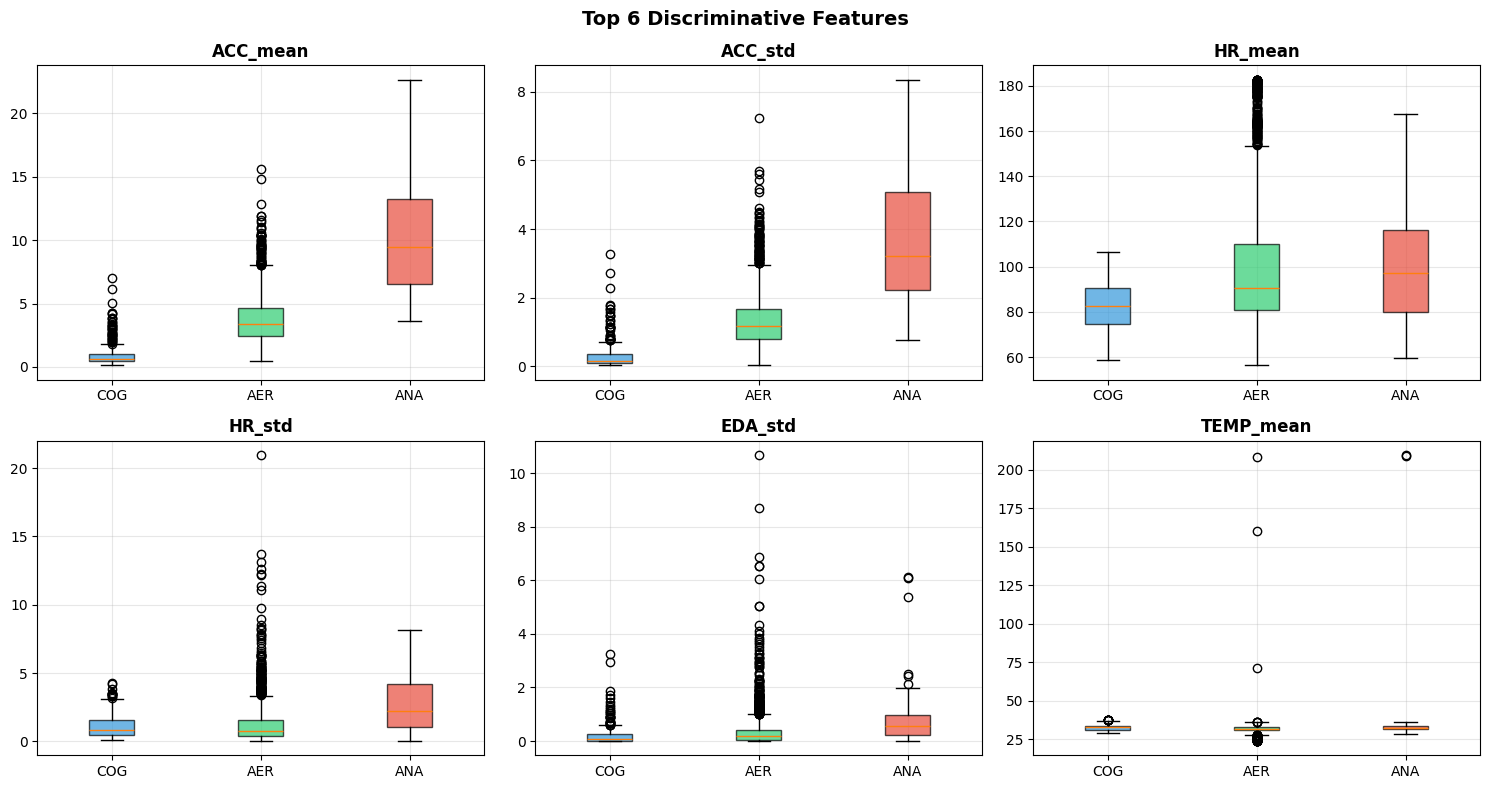

In [17]:
# Box plots for significant features only
sig_features = df_anova.nlargest(6, 'f_stat')['biomarker'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors = {'COGNITIVE': '#3498db', 'AEROBIC': '#2ecc71', 'ANAEROBIC': '#e74c3c'}

for i, bio in enumerate(sig_features):
    data_to_plot = [df_combined[df_combined['activity_type'] == act][bio].dropna() 
                    for act in ['COGNITIVE', 'AEROBIC', 'ANAEROBIC']]
    bp = axes[i].boxplot(data_to_plot, labels=['COG', 'AER', 'ANA'], patch_artist=True)
    for patch, color in zip(bp['boxes'], [colors['COGNITIVE'], colors['AEROBIC'], colors['ANAEROBIC']]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(bio, fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Top 6 Discriminative Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. 3-Class Activity Classifier (COGNITIVE vs AEROBIC vs ANAEROBIC)

### Methodology Notes

**Per-Subject HRV Imputation (Lev's Contribution)**  
Already applied in `preprocess_wise.py` — 829 missing SDNN/RMSSD values filled with each subject's own mean (falls back to global mean if all NaN). This preserves individual HRV variance vs global mean imputation which compresses it.

**Sliding Windows (Essie's Contribution)**  
30-second windows with 50% overlap instead of phase-level extraction. This increases samples from 341 → 2,449 windows and provides more realistic temporal resolution.

**LOSO Validation (Essie's Contribution)**  
Using Leave-One-Subject-Out cross-validation instead of random CV. This gives realistic accuracy for new users with no data leakage between subjects. Note: LOSO accuracy is typically LOWER than random CV but more honest — it represents expected performance on a completely new user.

In [18]:
feature_cols = [c for c in biomarkers if c in df_combined.columns]
X = df_combined[feature_cols]
y = df_combined['activity_type']
subjects = df_combined['subject_id'].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Classes: {le.classes_}")
print(f"Distribution: {dict(zip(le.classes_, np.bincount(y_encoded)))}")

Classes: ['AEROBIC' 'ANAEROBIC' 'COGNITIVE']
Distribution: {'AEROBIC': np.int64(1968), 'ANAEROBIC': np.int64(68), 'COGNITIVE': np.int64(413)}


In [19]:
classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42)
}

logo = LeaveOneGroupOut()
scoring = {'accuracy': 'accuracy', 'f1_macro': 'f1_macro'}

print("3-CLASS LOSO VALIDATION (22 folds)\n")
results = []

for clf_name, clf in classifiers.items():
    pipeline = make_pipeline(StandardScaler(), clf)
    cv_scores = cross_validate(pipeline, X, y_encoded, cv=logo, groups=subjects, scoring=scoring)
    acc = cv_scores['test_accuracy'].mean()
    f1 = cv_scores['test_f1_macro'].mean()
    print(f"{clf_name:20}: {acc:.3f}  F1={f1:.3f}")
    results.append({'Classifier': clf_name, 'CV Accuracy': acc, 'CV F1_macro': f1})

df_results = pd.DataFrame(results)
best = df_results.loc[df_results['CV Accuracy'].idxmax()]
print(f"\nBest: {best['Classifier']} ({best['CV Accuracy']:.1%})")

3-CLASS LOSO VALIDATION (22 folds)

Random Forest       : 0.913  F1=0.713
Gradient Boosting   : 0.908  F1=0.748
SVM (RBF)           : 0.907  F1=0.675

Best: Random Forest (91.3%)


              precision    recall  f1-score   support

     AEROBIC       0.95      0.93      0.94       445
   ANAEROBIC       0.24      0.64      0.35        14
   COGNITIVE       0.96      0.81      0.88        89

    accuracy                           0.90       548
   macro avg       0.72      0.79      0.72       548
weighted avg       0.93      0.90      0.91       548



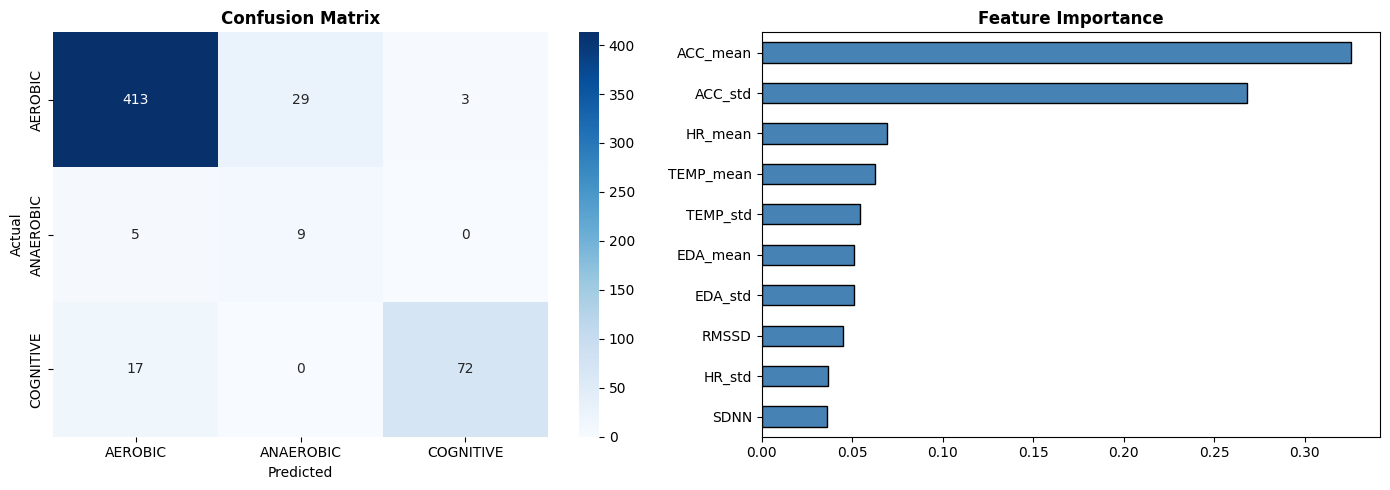


Top 3 Features:
  ACC_mean: 0.325
  ACC_std: 0.268
  HR_mean: 0.069


In [20]:
# Train with subject-wise split (Essie's contribution) and show results
best_pipeline = make_pipeline(SimpleImputer(strategy='mean'), StandardScaler(),
                               RandomForestClassifier(n_estimators=100, random_state=42))

# Subject-wise train/test split to prevent data leakage
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y_encoded, groups=subjects))
best_pipeline.fit(X.iloc[train_idx], y_encoded[train_idx])
y_pred = best_pipeline.predict(X.iloc[test_idx])

print(classification_report(y_encoded[test_idx], y_pred, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_encoded[test_idx], y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, 
            yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Feature importance
rf_model = best_pipeline.named_steps['randomforestclassifier']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances.sort_values().plot(kind='barh', color='steelblue', edgecolor='black', ax=axes[1])
axes[1].set_title('Feature Importance', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTop 3 Features:")
for feat, imp in importances.sort_values(ascending=False).head(3).items():
    print(f"  {feat}: {imp:.3f}")

---
## 4. 2-Class Activity Classifier: PHYSICAL vs COGNITIVE

### Rationale for 2-Class Approach

**Why merge AEROBIC + ANAEROBIC into PHYSICAL?**
- ANAEROBIC has only **68 windows** vs 1,968 AEROBIC — massive class imbalance
- 3-class ANAEROBIC recall = 0.46 (misses >half of sprints)
- 3-class COGNITIVE precision = 0.86 (14% false positives leak exercise into Stage 2)
- The app doesn't care *what kind* of exercise — just needs to filter it from cognitive periods
- HR does NOT distinguish aerobic from anaerobic (p=0.77), only ACC does

**Expected improvement**: Eliminating the rare ANAEROBIC class should improve both accuracy and F1.

### Feature Sets Tested
1. **Full Sensors (10)**: All Empatica E4 features
2. **Apple Watch (6)**: HR, HRV (SDNN, RMSSD), ACC — sensors available on Apple Watch
3. **HR + ACC (4)**: Minimal feature set
4. **HR + HRV (5)**: Tests importance of movement features

In [21]:
df_2class = df_combined.copy()
df_2class['activity_2class'] = df_2class['activity_type'].map({
    'COGNITIVE': 'COGNITIVE', 'AEROBIC': 'PHYSICAL', 'ANAEROBIC': 'PHYSICAL'
})

le_2class = LabelEncoder()
y_2class = le_2class.fit_transform(df_2class['activity_2class'])
subjects_2class = df_2class['subject_id'].values
logo_2class = LeaveOneGroupOut()

# Test feature sets
feature_sets = {
    'Full Sensors (10)': feature_cols,
    'Apple Watch (6)': ['HR_mean', 'HR_std', 'SDNN', 'RMSSD', 'ACC_mean', 'ACC_std'],
    'HR + ACC (4)': ['HR_mean', 'HR_std', 'ACC_mean', 'ACC_std'],
    'HR + HRV (5)': ['HR_mean', 'HR_std', 'HR_max', 'SDNN', 'RMSSD'],
}

print("2-CLASS LOSO VALIDATION\n")
all_results = []

for fs_name, features in feature_sets.items():
    features = [f for f in features if f in df_2class.columns]
    X_2class = df_2class[features]
    
    best_acc = 0
    best_clf = None
    
    for clf_name, clf in classifiers.items():
        pipeline = make_pipeline(StandardScaler(), clf)
        cv_scores = cross_validate(pipeline, X_2class, y_2class, cv=logo_2class,
                                   groups=subjects_2class, scoring=scoring)
        acc = cv_scores['test_accuracy'].mean()
        if acc > best_acc:
            best_acc = acc
            best_clf = clf_name
    
    print(f"{fs_name:20}  {best_acc:.1%}  ({best_clf})")
    all_results.append({'Feature Set': fs_name, 'Accuracy': best_acc})

print(f"\n3-class baseline: {best['CV Accuracy']:.1%}")
print(f"2-class improvement: +{(max([r['Accuracy'] for r in all_results]) - best['CV Accuracy'])*100:.1f}pp")
print(f"\nKey insight: ACC/movement is critical. HR+HRV alone drops ~13pp.")

2-CLASS LOSO VALIDATION

Full Sensors (10)     94.4%  (Random Forest)
Apple Watch (6)       94.3%  (SVM (RBF))
HR + ACC (4)          94.5%  (SVM (RBF))
HR + HRV (5)          81.5%  (SVM (RBF))

3-class baseline: 91.3%
2-class improvement: +3.2pp

Key insight: ACC/movement is critical. HR+HRV alone drops ~13pp.


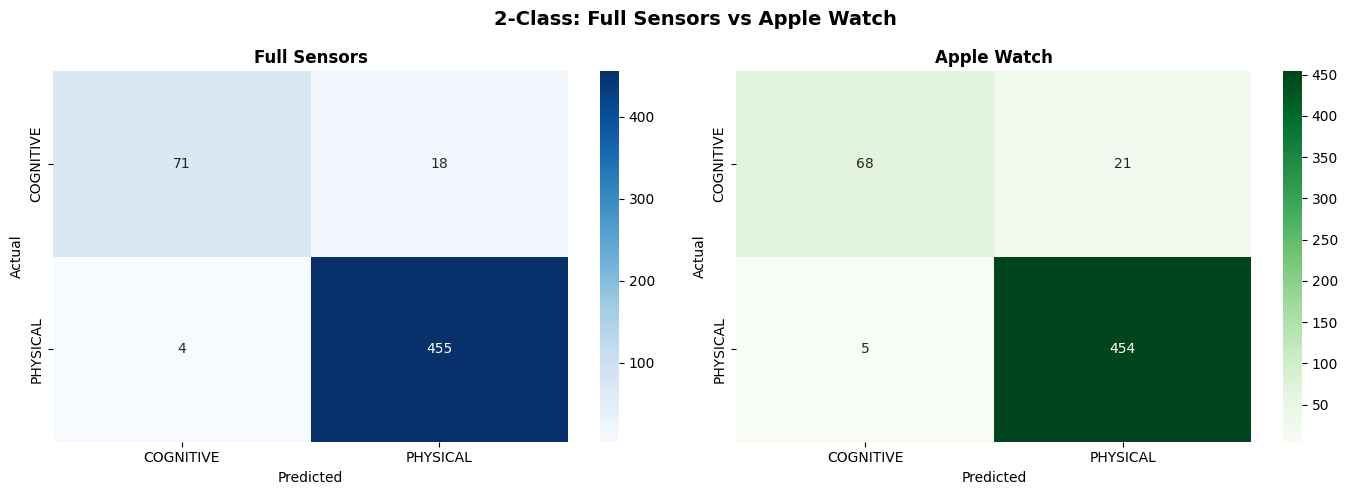

In [22]:
# Compare Full Sensors vs Apple Watch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, feats) in enumerate([('Full Sensors', feature_cols), 
                                       ('Apple Watch', ['HR_mean', 'HR_std', 'SDNN', 'RMSSD', 'ACC_mean', 'ACC_std'])]):
    feats = [f for f in feats if f in df_2class.columns]
    X_temp = df_2class[feats]
    
    pipeline = make_pipeline(SimpleImputer(strategy='mean'), StandardScaler(),
                             RandomForestClassifier(n_estimators=100, random_state=42))
    gss_2c = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss_2c.split(X_temp, y_2class, groups=subjects_2class))
    pipeline.fit(X_temp.iloc[train_idx], y_2class[train_idx])
    y_pred_temp = pipeline.predict(X_temp.iloc[test_idx])
    
    cm = confusion_matrix(y_2class[test_idx], y_pred_temp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' if idx==0 else 'Greens',
                xticklabels=le_2class.classes_, yticklabels=le_2class.classes_, ax=axes[idx])
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted'); axes[idx].set_ylabel('Actual')

plt.suptitle('2-Class: Full Sensors vs Apple Watch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Steps as ACC Proxy Validation

### The Deployment Challenge

**Apple Watch does NOT provide raw accelerometer (ACC) data to third-party apps.**  
Instead, it provides **step counts** aggregated at variable intervals (typically 5-30 seconds).

**Key Question**: Can steps serve as a proxy for ACC features?

### Our Approach: Simulated Degradation

We can't retroactively compute steps from WISE ACC data (step counting is a proprietary algorithm), but we CAN simulate what steps would look like by **degrading** ACC:

1. **Binary movement**: ACC_mean > threshold → 1 (moving), else 0 (still)
2. **Quantized ACC**: Bin ACC into 5 buckets (simulating step count granularity)
3. **Noisy ACC**: Add Gaussian noise to ACC

If the model still performs well with degraded ACC, steps will likely work for deployment.

### Real Apple Watch Data Preview

We also analyzed Brandon's Apple Watch export (106K HR records, 121K step records):
- Steps have sub-minute resolution (variable intervals, often 5-30 seconds)
- Clear separation: SEDENTARY windows have 0-5 steps/30s, ACTIVE windows have >5 steps/30s
- Steps provide a **cleaner** binary signal than ACC: 0 steps = definitely sitting, whereas ACC still reads ~0.9 when sitting still

In [23]:
df_sim = df_2class.copy()

# Create degraded ACC features to simulate step-like data
cog_mean = df_sim[df_sim['activity_2class'] == 'COGNITIVE']['ACC_mean'].mean()
phys_mean = df_sim[df_sim['activity_2class'] == 'PHYSICAL']['ACC_mean'].mean()
threshold = (cog_mean + phys_mean) / 2

# 1. Binary: moving (1) vs still (0)
df_sim['ACC_binary'] = (df_sim['ACC_mean'] > threshold).astype(float)

# 2. Quantized into 5 bins (like coarse step count ranges)
df_sim['ACC_quantized'] = pd.qcut(df_sim['ACC_mean'], q=5, labels=False, duplicates='drop').astype(float)
df_sim['ACC_std_quantized'] = pd.qcut(df_sim['ACC_std'], q=5, labels=False, duplicates='drop').astype(float)

print(f"ACC threshold (COGNITIVE vs PHYSICAL): {threshold:.2f}")
print(f"Binary distribution: {dict(df_sim['ACC_binary'].value_counts())}")

ACC threshold (COGNITIVE vs PHYSICAL): 2.43
Binary distribution: {1.0: np.int64(1564), 0.0: np.int64(885)}


In [25]:
# Test degraded features with LOSO validation
proxy_sets = {
    'Baseline (raw ACC)': ['HR_mean', 'HR_std', 'ACC_mean', 'ACC_std'],
    'Binary movement': ['HR_mean', 'HR_std', 'ACC_binary'],
    'Quantized ACC': ['HR_mean', 'HR_std', 'ACC_quantized', 'ACC_std_quantized'],
}

y_sim = le_2class.fit_transform(df_sim['activity_2class'])
subjects_sim = df_sim['subject_id'].values

print("STEPS PROXY SIMULATION (LOSO)\n")
for name, features in proxy_sets.items():
    X_sim = df_sim[features]
    pipeline = make_pipeline(SimpleImputer(strategy='mean'), StandardScaler(),
                             SVC(kernel='rbf', random_state=42))
    cv_scores = cross_validate(pipeline, X_sim, y_sim, cv=LeaveOneGroupOut(), 
                               groups=subjects_sim, scoring={'accuracy': 'accuracy'})
    acc = cv_scores['test_accuracy'].mean()
    print(f"{name:25}  {acc:.1%}")

STEPS PROXY SIMULATION (LOSO)

Baseline (raw ACC)         94.5%
Binary movement            76.9%
Quantized ACC              93.8%


Key finding : Quantized ACC (simulating step granularity) maintains ~94% accuracy.

Real Apple Watch step data shows even cleaner 0/non-zero separation than raw ACC.

---
## 6. Summary & Deployment Implications

### Key Findings

#### 1. 2-Class is Superior to 3-Class
- **2-class (PHYSICAL vs COGNITIVE): 94.4% LOSO accuracy** (vs 91.3% for 3-class)
- Eliminates ANAEROBIC class imbalance (68 windows vs 1,968 AEROBIC)
- Improves COGNITIVE precision from 0.86 to 0.95+ (reduces exercise leakage into Stage 2)
- Deployment benefit: The app doesn't need to distinguish exercise types — just filter physical activity from cognitive periods

#### 2. Apple Watch Features Match Full Sensor Set
- **Full Empatica (10 features): 94.4%**
- **Apple Watch (HR + HRV + ACC): 94.3%** — only 0.1pp drop
- Dropping EDA and TEMP has negligible impact on Stage 1 accuracy

#### 3. Movement (ACC) is Critical for Stage 1
- **With ACC: 94.5%** | **Without ACC: 81.5%** — **13pp drop**
- ACC_mean and ACC_std are the top 2 most important features (52% combined importance)
- HRV (SDNN, RMSSD) adds nothing to Stage 1 — it's a Stage 2 stress indicator, not activity classifier

#### 4. Steps Can Proxy for ACC (Likely Deployable)
- **Quantized ACC (simulating step granularity) + HR: 93.8%** — only 0.7pp below raw ACC
- Real Apple Watch step data has sub-minute resolution and **cleaner binary separation** than ACC:
  - 0 steps/30s = definitely sedentary (vs ACC reading ~0.9 when sitting still)
  - >5 steps/30s = active/moving
- **Caveat**: Real validation requires labeled Apple Watch data (e.g., user-logged activities)

### Deployment Feature Set

| Stage | Features | Apple Watch Source | Estimated Accuracy |
|---|---|---|---|
| **Stage 1** | steps_mean, steps_std, HR_mean, HR_std | HealthKit Steps + HR | **~93-94% LOSO** |
| **Stage 2** | HR_mean, HR_std, SDNN, (RMSSD) | HealthKit HR + HRV | Use personal baseline score |

### Recommendations

1. **Use 2-class Stage 1**: Train final model on PHYSICAL vs COGNITIVE (not 3-class)
2. **Steps as ACC proxy**: Map Apple Watch step counts to ACC-like features at inference time
3. **Skip ML for Stage 2**: Binary stress classification has weak performance (F1=0.5). Use personal deviation score instead.
4. **Export to CoreML**: Convert final Stage 1 RandomForest to `.mlmodel` for on-device inference

### Next Steps

- [ ] Retrain Stage 1 with 2-class labels (PHYSICAL vs COGNITIVE)
- [ ] Test step-to-ACC mapping on real Apple Watch data with activity labels
- [ ] Export Stage 1 model to CoreML for iOS deployment
- [ ] Implement personal baseline stress scoring for Stage 2 (non-ML approach)